## Analytic Gaussian $P_4$ Bond Information ##

This notebook will generate figure 3a in the report; this is the figure analysing the values of the Bond Information for the 4-element path graph $P_4$ in the Gaussian case, for which the Tsallis-Alpha has an analytic expression and we can calculate the Bond Information analytically. After producing the figure, the x-axis labelling and table were created in Inkscape.

In [1]:
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
from Modules.brute_force_bond_finder import brute_force_bond_finder
from Modules.gaussian_testing import covariance_matrix_bond, analytic_gaussian_bi
from Modules.moebius_machinery import mat_vec_solve_mu

In [3]:
# Generate bonds for P_4 and all 4-element partitions (bonds for complete graph K_4)

P_4 = nx.path_graph(4)
K_4 = nx.complete_graph(4)
bonds_P_4 = brute_force_bond_finder(P_4)
partitions = brute_force_bond_finder(K_4) # all 4-element partitions

In [ ]:
# Organise four-element partitions by whether they are a bond in path graph P_4 or not

# Initiate list with all the bonds of P_4
bondlist = [bond for bond in bonds_P_4]

# Now append non-bond partitions
for bond in partitions:
    if bond not in bonds_P_4:
        bondlist.append(bond)


In [ ]:
# Calculate bond information for all of the different factorisations of the joint Gaussian distribution

bond_information_list = []

# Calculate for all 4-element partitions, bond or non-bond
for bond in bondlist:

    # Covariance to induce joint factorisation according to current bond. Correlation strength between independent variables 0.8
    sigma = covariance_matrix_bond(4, bond, 0.8)

    # Calculate and append
    bond_information_list.append(analytic_gaussian_bi(P_4, brute_force_bond_finder, sigma))

# This part was used to identify which non-bond partitions the bond information was vanishing for
for i in range(len(partitions)):
    print(bondlist[i] in bonds_P_4)
    print(bondlist[i], bond_information_list[i])



True
[[0], [1], [2], [3]] 0.0
True
[[0], [1], [2, 3]] 0.0
True
[[0], [1, 2], [3]] 0.0
True
[[0, 1], [2], [3]] 0.0
True
[[0], [1, 2, 3]] 0.0
True
[[0, 1], [2, 3]] 0.0
True
[[0, 1, 2], [3]] 0.0
True
[[0, 1, 2, 3]] 0.0012350903462494678
False
[[0], [2], [1, 3]] 0.0
False
[[1], [0, 2], [3]] 0.0
False
[[1], [2], [0, 3]] 0.30969149054296663
False
[[0, 2], [1, 3]] -0.04795440965736186
False
[[1], [0, 2, 3]] -0.030297906056894863
False
[[1, 2], [0, 3]] 0.26173708088560477
False
[[2], [0, 1, 3]] -0.030297906056894863


In [ ]:
# Used to get all of the Moebius coefficients in the table (figure 3b)
_, _, mu = mat_vec_solve_mu(bonds_P_4)
print(mu)

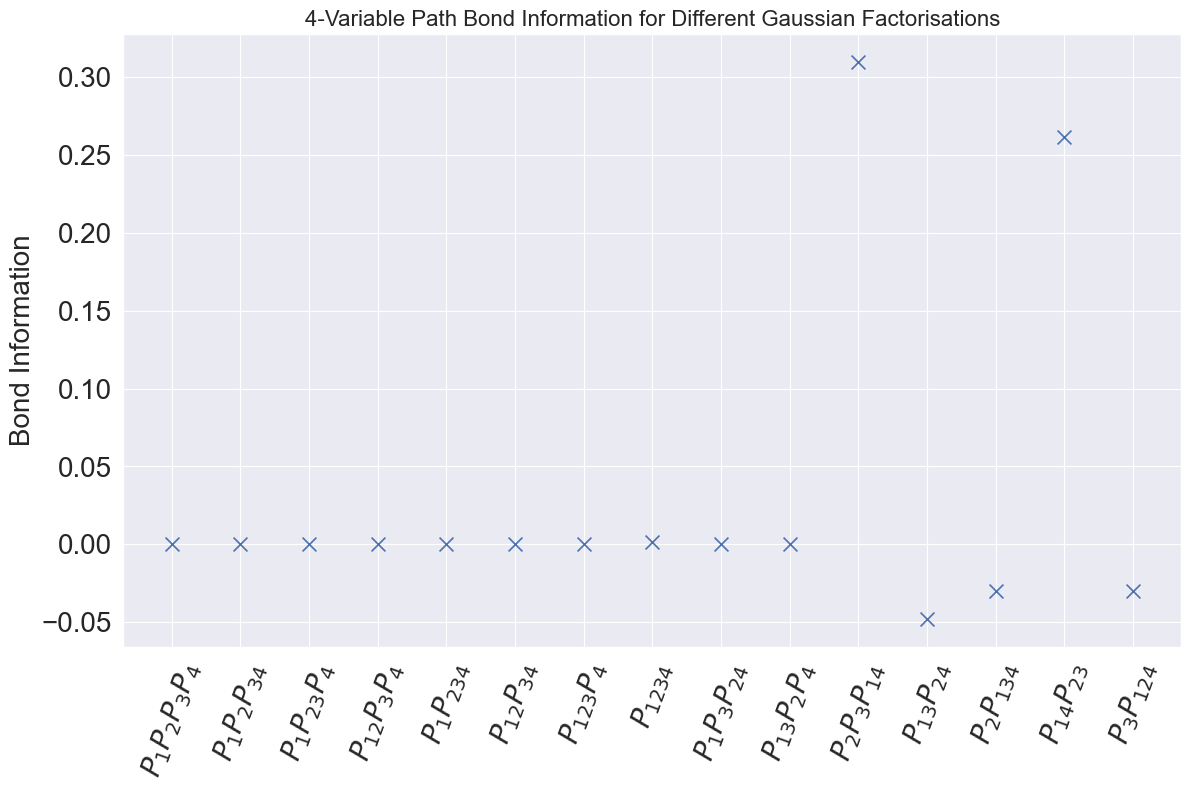

In [ ]:
# Plotting
sns.set_theme(style="darkgrid", context="paper")

fig, ax = plt.subplots(figsize=(12, 8))

x = range(15)

ax.scatter(x, bond_information_list, marker="x", s=100)

ax.set_xticks(x)

ax.set_xticklabels([
    r"$P_1P_2P_3P_4$",
    r"$P_1P_2P_{34}$",
    r"$P_1P_{23}P_4$",
    r"$P_{12}P_3P_4$",
    r"$P_1P_{234}$",
    r"$P_{12}P_{34}$",
    r"$P_{123}P_4$",
    r"$P_{1234}$",
    r"$P_1P_3P_{24}$",
    r"$P_{13}P_2P_4$",
    r"$P_2P_3P_{14}$",
    r"$P_{13}P_{24}$",
    r"$P_2P_{134}$",
    r"$P_{14}P_{23}$",
    r"$P_3P_{124}$",
], rotation=70)

ax.set_ylabel("Bond Information", fontsize=20)
ax.tick_params(labelsize=20)
ax.set_title(r"4-Variable Path Bond Information for Different Gaussian Factorisations", fontsize=16)

plt.tight_layout()
plt.savefig(r"C:\Users\morit\Thesis_Repo\Plots\four_path_bi_gaussian.png")